In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm
from genkit import DLPMEps, DLPMEpsC, GaussianFlowLinear, TEDMOrigin, DLPMEpsOrigin
from genkit.datasets import fetch_synthetic_data
from genkit.inspect import estimate_init_error, estimate_training_loss_error, model_est_err_curve, model_est_jacobian_spectral_curve
from genkit.metrics import mmd_rbf, sliced_wasserstein, tail_coverage_error
from genkit.nn import MLPModel
from genkit.training import train
from genkit.visitor import CoreMetricsVisitor, TrainVisitor
from labkit.report import format_mean_std_latex, summarize_metric_values, PRETTY_RCPARAMS

plt.rcParams.update(PRETTY_RCPARAMS)


In [7]:
def mean_curve(model_runs, key):
    curves = [np.asarray(run[key], dtype=float) for run in model_runs if len(run[key])]
    if not curves:
        return np.empty((0,), dtype=float)
    size = min(curve.shape[0] for curve in curves)
    return np.stack([curve[:size] for curve in curves], axis=0).mean(axis=0)


def stack_curves(model_runs, key):
    curves = [np.asarray(run[key], dtype=float) for run in model_runs if len(run[key])]
    if not curves:
        return np.empty((0, 0), dtype=float)
    size = min(curve.shape[0] for curve in curves)
    return np.stack([curve[:size] for curve in curves], axis=0)


def smooth_rows(values, window: int = 5):
    values = np.asarray(values, dtype=float)
    if values.ndim != 2 or values.shape[1] < 2 or int(window) <= 1:
        return values
    window = int(window)
    if window % 2 == 0:
        window += 1
    if values.shape[1] < window:
        window = values.shape[1] if values.shape[1] % 2 == 1 else max(values.shape[1] - 1, 1)
    if window <= 1:
        return values
    pad = window // 2
    kernel = np.full(window, 1.0 / window, dtype=float)
    padded = np.pad(values, ((0, 0), (pad, pad)), mode="edge")
    return np.vstack([np.convolve(row, kernel, mode="valid") for row in padded])


def plot_band(ax, mean, std=None, *, color, linestyle="solid", lw=2.0, alpha=0.6, fill_alpha=0.1, label=None, marker=None, lower_clip=None, x_values=None):
    mean = np.asarray(mean, dtype=float)
    if mean.size == 0 or np.all(~np.isfinite(mean)):
        return
    x_values = np.arange(len(mean)) if x_values is None else np.asarray(x_values)
    if lower_clip is not None:
        mean = np.maximum(mean, float(lower_clip))
    plot_kwargs = {"color": color, "linestyle": linestyle, "lw": lw, "alpha": alpha}
    if label is not None:
        plot_kwargs["label"] = label
    if marker is not None:
        plot_kwargs["marker"] = marker
    ax.plot(x_values, mean, **plot_kwargs)
    if std is None:
        return
    std = np.asarray(std, dtype=float)
    if std.shape != mean.shape or np.all(~np.isfinite(std)):
        return
    lower = mean - std
    upper = mean + std
    if lower_clip is not None:
        lower = np.maximum(lower, float(lower_clip))
        upper = np.maximum(upper, float(lower_clip))
    ax.fill_between(x_values, lower, upper, color=color, alpha=fill_alpha)


def render_dataframe_table(ax, frame, *, col_labels=None, fontsize=8.5, scale=(1.0, 1.35)):
    ax.axis("off")
    table = ax.table(cellText=frame.values, rowLabels=frame.index, colLabels=list(frame.columns) if col_labels is None else list(col_labels), loc="center", cellLoc="center")
    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(*scale)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("0.2")
        cell.set_linewidth(0.6)
        if row == 0 or col == -1:
            cell.set_text_props(weight="bold")
    return table


def summarize_metric_frame(df, metric_names, source_order):
    rows = []
    for model_name in source_order:
        model_df = df[df["model"] == model_name]
        row = {"model": model_name}
        for metric_name in metric_names:
            stats = summarize_metric_values(model_df[metric_name].tolist())
            row[metric_name] = stats["mean"]
            row[f"{metric_name}_std"] = stats["std"]
        rows.append(row)
    return pd.DataFrame(rows).set_index("model").loc[source_order]


def summarize_nested_metric_frame(df, metric_names, source_order):
    rows = []
    for model_name in source_order:
        model_df = df[df["model"] == model_name]
        row = {"model": model_name}
        for metric_name in metric_names:
            row[metric_name] = summarize_metric_values(model_df[metric_name].tolist())
        rows.append(row)
    return pd.DataFrame(rows).set_index("model").loc[source_order]


def format_mean_std_table(summary_df, metric_names, *, best_by_metric=None):
    table = pd.DataFrame(index=summary_df.index, columns=list(metric_names), dtype=object)
    best_by_metric = {} if best_by_metric is None else dict(best_by_metric)
    for metric_name in metric_names:
        best_model = None
        if best_by_metric.get(metric_name) == "min":
            best_model = summary_df[metric_name].idxmin()
        elif best_by_metric.get(metric_name) == "max":
            best_model = summary_df[metric_name].idxmax()
        for model_name in summary_df.index:
            table.loc[model_name, metric_name] = format_mean_std_latex(summary_df.loc[model_name, metric_name], summary_df.loc[model_name, f"{metric_name}_std"], bold=model_name == best_model)
    return table


def safe_inspect_scalar(model, fn, *args, **kwargs):
    if getattr(model, "_family", None) == "vendor":
        return float("nan")
    return float(fn(model, *args, **kwargs))


def safe_inspect_curve(model, fn, *args, length, **kwargs):
    if getattr(model, "_family", None) == "vendor":
        return np.full(int(length), np.nan, dtype=float)
    return np.asarray(fn(model, *args, **kwargs), dtype=float)


def format_mean_std_or_na(stats, *, bold=False):
    mean = float(stats["mean"])
    std = float(stats["std"])
    if not np.isfinite(mean):
        return "N/A"
    if not np.isfinite(std):
        std = 0.0
    return format_mean_std_latex(max(0.0, mean), std, bold=bold)


def first_curve_length(curve_map):
    for curves in curve_map.values():
        if curves:
            return int(np.asarray(curves[0], dtype=float).shape[0])
    return 0


In [8]:
class TestSampleMetricsVisitor(TrainVisitor):
    """Visitor that tracks held-out sample-quality metrics across epochs."""

    name = "test_sample_metrics"

    def __init__(self, test_data, sample_probe_size: int = 512, tail_probe_size: int = 4096, random_state: int = 0):
        self._test_data = None if test_data is None else test_data.detach().cpu()
        self._sample_probe_size = int(sample_probe_size)
        self._tail_probe_size = int(tail_probe_size)
        self._random_state = int(random_state)
        self.sample_probe_size = 0
        self.tail_probe_size = 0
        self.test_mse_epoch = []
        self.test_sw_epoch = []
        self.test_mmd_rbf_epoch = []
        self.test_tce_999_epoch = []
        self._sample_x = None
        self._tail_x = None

    def _sample_rows(self, data, n: int, *, seed_offset: int):
        if data is None:
            return None
        data_cpu = data.detach().cpu()
        if data_cpu.size(0) == 0 or n <= 0:
            return None
        n = min(int(n), int(data_cpu.size(0)))
        generator = torch.Generator(device="cpu")
        generator.manual_seed(self._random_state + int(seed_offset))
        if n == data_cpu.size(0):
            idx = torch.arange(data_cpu.size(0), device="cpu")
        else:
            idx = torch.randperm(data_cpu.size(0), generator=generator)[:n]
        return data_cpu.index_select(0, idx)

    def _fork_devices(self, device: torch.device):
        if device.type != "cuda":
            return []
        return [0 if device.index is None else int(device.index)]

    def _sample_generated(self, generative_model, n: int, *, seed_offset: int):
        if n <= 0:
            return None
        device = torch.device(getattr(generative_model, "_device", "cpu"))
        fdtype = getattr(generative_model, "_fdtype", None)
        with torch.random.fork_rng(devices=self._fork_devices(device)):
            torch.manual_seed(self._random_state + int(seed_offset))
            if device.type == "cuda":
                torch.cuda.manual_seed_all(self._random_state + int(seed_offset))
            x_gen = generative_model.sample(int(n))
        x_gen = x_gen.detach().to(device=device)
        if fdtype is not None:
            x_gen = x_gen.to(dtype=fdtype)
        return x_gen

    def on_train_start(self, target, source, config, generative_model=None, net=None):
        if generative_model is None or net is None:
            raise ValueError("TestSampleMetricsVisitor requires both generative_model and net.")
        param = next(net.parameters(), None)
        if param is None:
            raise ValueError("TestSampleMetricsVisitor requires a network with parameters.")
        device = param.device
        dtype = param.dtype
        self._sample_x = self._sample_rows(self._test_data, self._sample_probe_size, seed_offset=0)
        if self._sample_x is not None:
            self._sample_x = self._sample_x.to(device=device, dtype=dtype)
        self.sample_probe_size = 0 if self._sample_x is None else int(self._sample_x.size(0))
        self._tail_x = self._sample_rows(self._test_data, self._tail_probe_size, seed_offset=1)
        if self._tail_x is not None:
            self._tail_x = self._tail_x.to(device=device, dtype=dtype)
        self.tail_probe_size = 0 if self._tail_x is None else int(self._tail_x.size(0))

    def on_epoch_end(self, generative_model=None, net=None):
        if generative_model is None:
            return
        was_training = False if net is None else net.training
        if net is not None:
            net.eval()
        try:
            if self._sample_x is not None:
                device = torch.device(getattr(generative_model, "_device", "cpu"))
                if getattr(generative_model, "_family", None) == "vendor":
                    self.test_mse_epoch.append(float("nan"))
                else:
                    with torch.random.fork_rng(devices=self._fork_devices(device)):
                        torch.manual_seed(self._random_state + 4)
                        if device.type == "cuda":
                            torch.cuda.manual_seed_all(self._random_state + 4)
                        self.test_mse_epoch.append(float(estimate_training_loss_error(generative_model, self._sample_x, n_batches=1, batch_size=self.sample_probe_size, loss_type="mse")))
                x_gen = self._sample_generated(generative_model, self.sample_probe_size, seed_offset=2)
                self.test_sw_epoch.append(float(sliced_wasserstein(self._sample_x, x_gen)))
                self.test_mmd_rbf_epoch.append(float(mmd_rbf(self._sample_x, x_gen)))
            else:
                self.test_mse_epoch.append(float("nan"))
                self.test_sw_epoch.append(float("nan"))
                self.test_mmd_rbf_epoch.append(float("nan"))
            if self._tail_x is not None:
                x_gen_tail = self._sample_generated(generative_model, self.tail_probe_size, seed_offset=3)
                probs = torch.tensor([1e-3], device=self._tail_x.device, dtype=self._tail_x.dtype)
                self.test_tce_999_epoch.append(float(tail_coverage_error(self._tail_x, x_gen_tail, probs=probs, tail="upper", mode="log", reduction="mean")))
            else:
                self.test_tce_999_epoch.append(float("nan"))
        finally:
            if was_training and net is not None:
                net.train()

    def format_epoch_log(self):
        if not self.test_sw_epoch:
            return ""
        return f"mse {self.test_mse_epoch[-1]:.3e} | sw {self.test_sw_epoch[-1]:.3e} | mmd {self.test_mmd_rbf_epoch[-1]:.3e} | tce999 {self.test_tce_999_epoch[-1]:.3e}"

    def get_records(self):
        return {
            "sample_probe_size": self.sample_probe_size,
            "tail_probe_size": self.tail_probe_size,
            "test_mse_epoch": self.test_mse_epoch,
            "test_sw_epoch": self.test_sw_epoch,
            "test_mmd_rbf_epoch": self.test_mmd_rbf_epoch,
            "test_tce_999_epoch": self.test_tce_999_epoch,
        }


In [ ]:
depth = 4
width = 256
time_dim = 32
n_steps = 128
grad_clip_norm = 5.0
n_trials = 2
n_epochs = 512
use_adamw = False
num_workers = 0
device = "cpu"
fdtype = torch.float32
idtype = torch.int32

model_specs = [
    {"name": "DLPM-E-C",
     "cls": DLPMEpsC,
     "source_distri": "Alpha-stable",
     "extra_kwargs": {"alpha": 1.6, "n_trial_A": 3},
     "train_kwargs": {"lr": 5e-4, "batch_size": 2048, "n_epochs": n_epochs, "grad_clip_norm": grad_clip_norm},
     "color": "tab:red",
     "linestyle": "dotted",
     "marker": "o",
     },
    {"name": "TEDM-Orig",
     "cls": TEDMOrigin,
     "source_distri": "Student-t",
     "extra_kwargs": {"nu": 10},
     "train_kwargs": { "lr": 5e-4, "batch_size": 2048, "n_epochs": n_epochs, "grad_clip_norm": grad_clip_norm},
     "color": "tab:green",
     "linestyle": "dashdot",
     "marker": "D",
     },
    {"name": "DLPM-E-Orig",
     "cls": DLPMEpsOrigin,
     "source_distri": "Alpha-stable",
     "extra_kwargs": {"alpha": 1.6, "loss_monte_carlo": "mean", "monte_carlo_outer": 3},
     "train_kwargs": {"lr": 5e-4, "batch_size": 2048, "n_epochs": n_epochs, "grad_clip_norm": grad_clip_norm},
     "color": "tab:brown",
     "linestyle": "dashed",
     "marker": "P",
     },
    {"name": "DLPM-E",
     "cls": DLPMEps,
     "source_distri": "Alpha-stable",
     "extra_kwargs": {"alpha": 1.6, "n_trial_A": 3},
     "train_kwargs": {"lr": 5e-4, "batch_size": 2048, "n_epochs": n_epochs, "grad_clip_norm": grad_clip_norm},
     "color": "tab:orange",
     "linestyle": "dotted",
     "marker": "^",
     },
    {"name": "GF-Linear",
     "cls": GaussianFlowLinear,
     "source_distri": "Gaussian",
     "extra_kwargs": {},
     "train_kwargs": {"lr": 1e-3, "batch_size": 2048, "n_epochs": n_epochs, "grad_clip_norm": grad_clip_norm},
     "color": "tab:blue",
     "linestyle": "solid",
     "marker": "s",
     },
]

source_order = [spec["name"] for spec in model_specs]
source_colors = {spec["name"]: spec["color"] for spec in model_specs}
tail_metric_names = ["TCE(95%)", "TCE(99%)", "TCE(99.9%)", "TCE(99.99%)"]
tail_metric_grid = np.array([0.95, 0.99, 0.999, 0.9999])

figures_dir = Path("figures")
figures_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
runs = []
trial_refs = {}
total_runs = n_trials * len(model_specs)

with tqdm(total=total_runs, initial=0, desc="Training models") as pbar:

    for trial_idx in range(n_trials):

        x_train, _, x_ref = fetch_synthetic_data("alpha_stable", alpha=1.7, n_samples=20_000, val_size=0.0001, test_size=0.5, dim=10, device=device, dtype=fdtype)
        n_train, dim = x_train.shape
        n_test, _ = x_ref.shape
        trial_refs[trial_idx] = x_ref.clone()

        for spec in model_specs:

            visitors=[CoreMetricsVisitor(),
                      TestSampleMetricsVisitor(test_data=x_ref, random_state=trial_idx),
                      ]
            net = MLPModel(input_dim=dim + 1 if (spec["cls"] is DLPMEpsC) else dim, output_dim=dim, width=width, depth=depth, time_dim=time_dim)
            generator = spec["cls"](net=net.to(device=device, dtype=fdtype), dim=dim, n_steps=n_steps, device=device, fdtype=fdtype, idtype=idtype, **spec["extra_kwargs"])
            train_kwargs = {"use_adamw": use_adamw, "num_workers": num_workers, "device": device, **spec.get("train_kwargs", {})}

            generator, diagnostics = train(generative_model=generator, target_data=x_train.clone(), visitors=visitors, **train_kwargs)

            train_metrics = diagnostics.get("visitors", {}).get("core", {})
            test_metrics = diagnostics.get("visitors", {}).get("test_sample_metrics", {})

            run_record = {
                "trial_idx": trial_idx,
                "model": spec["name"],
                "source_distri": spec["source_distri"],
                "extra_kwargs": dict(spec["extra_kwargs"]),
                "train_kwargs": dict(train_kwargs),
                "generator": generator,
                "training_loss": train_metrics.get("training_loss", []),
                "training_loss_std": train_metrics.get("training_loss_std", []),
                "grad_variance_epoch": train_metrics.get("grad_variance_epoch", []),
                "grad_norm_epoch": train_metrics.get("grad_norm_epoch", []),
                "test_mse_epoch": test_metrics.get("test_mse_epoch", []),
                "test_sw_epoch": test_metrics.get("test_sw_epoch", []),
                "test_mmd_rbf_epoch": test_metrics.get("test_mmd_rbf_epoch", []),
                "test_tce_999_epoch": test_metrics.get("test_tce_999_epoch", []),
            }

            pbar.update(1)
            runs.append(run_record)


Training models:  10%|█         | 1/10 [01:33<13:58, 93.12s/it]Warp CUDA warning: Could not find or load the NVIDIA CUDA driver. GPU execution will not be available.


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


Training models:  60%|██████    | 6/10 [11:48<08:13, 123.35s/it]/home/hcherkaoui/src/flowbench/src/genkit/_vendor/physicsnemo/physicsnemo/utils/logging/launch.py:327: SyntaxWarning: invalid escape sequence '\.'
  key = re.sub("[^a-zA-Z0-9\.\-\s\/\_]+", "", key)
Training models: 100%|██████████| 10/10 [19:23<00:00, 116.33s/it]


In [11]:
curve_runs =  {name: [run for run in runs if run["model"] == name] for name in source_order}
jacobian_runs = {name: [] for name in source_order}
err_t_runs = {name: [] for name in source_order}
eval_rows, tail_curves, inspect_rows, failures = [], [], [], []
inspect_max_n_steps = 16

for run in tqdm(runs, desc="Evaluating models"):

    x_ref = trial_refs[run["trial_idx"]]
    x_gen = run["generator"].sample(n_samples=len(x_ref))
    tail_errors = tail_coverage_error(x_ref, x_gen, probs=1.0 - tail_metric_grid, tail="upper", mode="log", reduction="none").mean(dim=1).cpu().numpy()

    eval_rows.append({"model": run["model"],
                      "trial_idx": run["trial_idx"],
                      "source_distri": run["source_distri"],
                      "SW": float(sliced_wasserstein(x_ref, x_gen)),
                      "MMD-RBF": float(mmd_rbf(x_ref, x_gen)),
                      **{name: float(value) for name, value in zip(tail_metric_names, tail_errors)},
                      })

    tail_curves.append({"model": run["model"], "trial_idx": run["trial_idx"], "tail_error": tail_errors.copy()})

    inspect_rows.append({"model": run["model"],
                         "trial_idx": run["trial_idx"],
                         "err_init": safe_inspect_scalar(run["generator"], estimate_init_error, x_ref, n_samples=2048, k=10),
                         "err_train": safe_inspect_scalar(run["generator"], estimate_training_loss_error, x_ref, n_batches=16, batch_size=256, loss_type="mse"),
                         })

    err_t_runs[run["model"]].append(safe_inspect_curve(run["generator"], model_est_err_curve, x_ref[:128, :], loss_type='mse', max_n_steps=inspect_max_n_steps, length=inspect_max_n_steps))

    jacobian_runs[run["model"]].append(safe_inspect_curve(run["generator"], model_est_jacobian_spectral_curve, x_ref[:128, :], n_power_iter=8, max_n_steps=inspect_max_n_steps, length=inspect_max_n_steps))


Evaluating models: 100%|██████████| 10/10 [13:24<00:00, 80.41s/it]


In [12]:
eval_metrics = ("SW", "MMD-RBF", "TCE(95%)", "TCE(99%)", "TCE(99.9%)", "TCE(99.99%)")

summary_df = summarize_metric_frame(pd.DataFrame(eval_rows), eval_metrics, source_order)
formatted = format_mean_std_table(summary_df, eval_metrics, best_by_metric={metric_name: "min" for metric_name in eval_metrics})
inspect_summary = summarize_nested_metric_frame(pd.DataFrame(inspect_rows), ("err_init", "err_train"), source_order)

training_metric_specs = [
    {"key": "training_loss", "label": "Train Loss", "yscale": "log", "ylim": (0.1, 1)},
    {"key": "training_loss_std", "label": "Train Loss Std", "yscale": "log", "ylim": (None, None)},
    {"key": "grad_variance_epoch", "label": "Grad Variance", "yscale": "log", "ylim": (None, None)},
    {"key": "grad_norm_epoch", "label": "Grad Norm", "yscale": "log", "ylim": (None, None)},
    {"key": "test_mse_epoch", "label": "Test MSE", "yscale": "log", "ylim": (0.5, 10)},
    {"key": "test_sw_epoch", "label": "Test SW", "yscale": "log", "ylim": (0.1, 1_000_000)},
    {"key": "test_mmd_rbf_epoch", "label": "Test MMD-RBF", "yscale": "log", "ylim": (None, None)},
    {"key": "test_tce_999_epoch", "label": "Test TCE(99.9%)", "yscale": "log", "ylim": (0.1, 100)},
]
training_curves = {spec["key"]: {name: stack_curves(curve_runs[name], spec["key"]) for name in source_order} for spec in training_metric_specs}


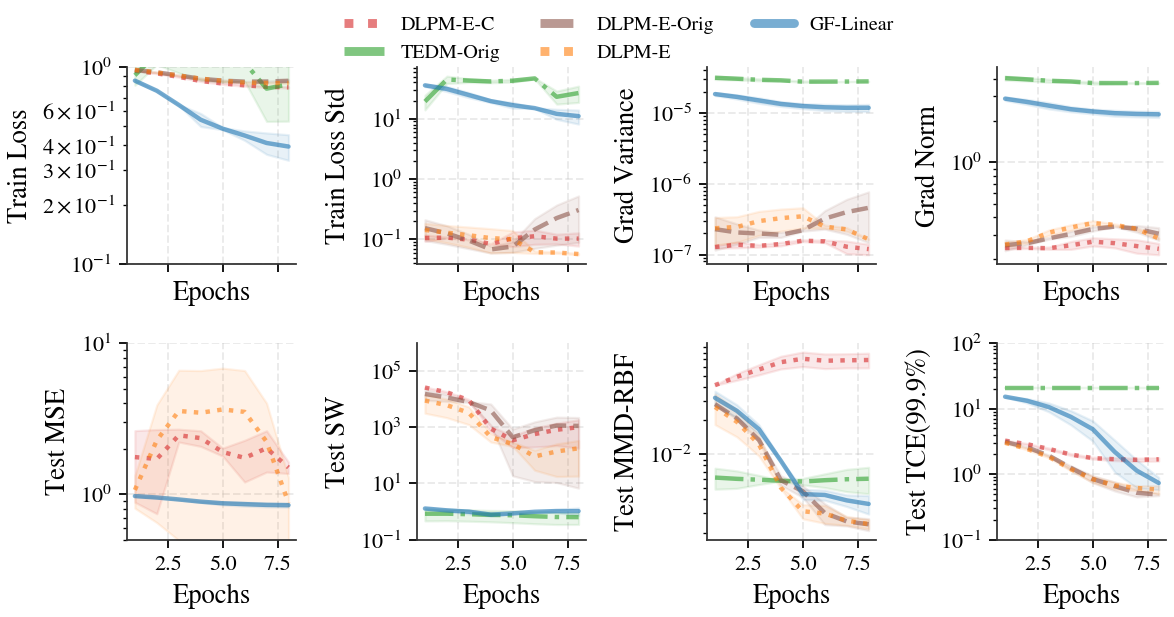

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(8.0, 4.0), squeeze=False, sharex=True)
for ax, metric_spec in zip(axes.reshape(-1), training_metric_specs):
    for model_spec in model_specs:
        values = training_curves[metric_spec["key"]][model_spec["name"]]
        if metric_spec["key"] in ["training_loss", "test_mse_epoch"]:
            values = values / np.clip(values[:, :1], 1e-12, None)
        values = smooth_rows(values, window=5)
        plot_band(ax, values.mean(axis=0), values.std(axis=0), color=source_colors[model_spec["name"]],
                  linestyle=model_spec["linestyle"], lw=2.0, alpha=0.6, fill_alpha=0.1, lower_clip=1e-12,
                  x_values=np.arange(1, values.shape[1] + 1))
    ax.set_ylabel(metric_spec["label"])
    ax.set_xlabel("Epochs")
    ax.set_yscale(metric_spec["yscale"])
    ax.set_ylim(*metric_spec["ylim"])

legend_handles =  [Line2D([0], [0], color=source_colors[spec["name"]], lw=4.0, linestyle=spec["linestyle"], label=spec["name"], alpha=0.6) for spec in model_specs]
fig.legend(legend_handles, [handle.get_label() for handle in legend_handles], loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 0.95, 0.95))

plt.savefig(figures_dir / "training_curves.png", dpi=300)
plt.show()


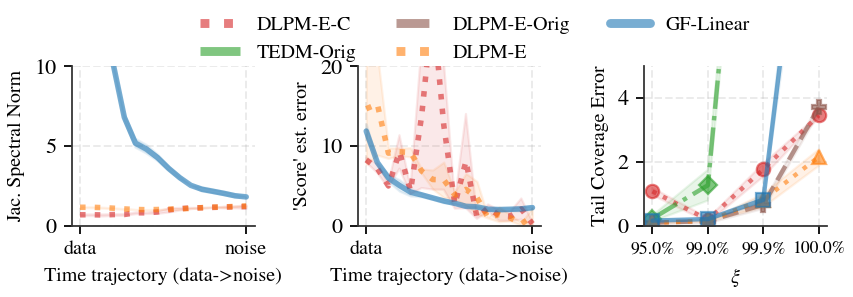

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(6.2, 2.0), squeeze=False)

inspect_curve_len = max(first_curve_length(jacobian_runs), first_curve_length(err_t_runs))

for spec in model_specs:
    if jacobian_runs[spec["name"]]:
        values_jacobian_runs = np.stack(jacobian_runs[spec["name"]], axis=0)
        plot_band(axes[0, 0], values_jacobian_runs.mean(axis=0), values_jacobian_runs.std(axis=0), color=source_colors[spec["name"]], linestyle=spec["linestyle"], lw=2.5, alpha=0.6, fill_alpha=0.1, label=spec["name"], lower_clip=1e-12)

    if err_t_runs[spec["name"]]:
        values_err_t_runs = np.stack(err_t_runs[spec["name"]], axis=0)
        plot_band(axes[0, 1], values_err_t_runs.mean(axis=0), values_err_t_runs.std(axis=0), color=source_colors[spec["name"]], linestyle=spec["linestyle"], lw=2.5, alpha=0.6, fill_alpha=0.1, label=spec["name"], lower_clip=1e-12)

    values_tail_error = np.stack([np.asarray(curve["tail_error"], dtype=float) for curve in tail_curves if curve["model"] == spec["name"]], axis=0)
    plot_band(axes[0, 2], values_tail_error.mean(axis=0), values_tail_error.std(axis=0), color=source_colors[spec["name"]], linestyle=spec["linestyle"], lw=2.0, alpha=0.6, fill_alpha=0.1, label=spec["name"], marker=spec["marker"])

axes[0, 0].set_ylim(0, 10)
if inspect_curve_len > 0:
    axes[0, 0].set_xticks([0, inspect_curve_len - 1], ["data", "noise"], fontsize=9)
axes[0, 0].set_ylabel("Jac. Spectral Norm", fontsize=9)
axes[0, 0].set_xlabel("Time trajectory (data->noise)", fontsize=9)

axes[0, 1].set_ylim(0, 20)
if inspect_curve_len > 0:
    axes[0, 1].set_xticks([0, inspect_curve_len - 1], ["data", "noise"], fontsize=9)
axes[0, 1].set_ylabel("'Score' est. error", fontsize=9)
axes[0, 1].set_xlabel("Time trajectory (data->noise)", fontsize=9)

axes[0, 2].set_ylim(0, 5)
axes[0, 2].set_xticks(np.arange(values_tail_error.shape[1]), [f"{xi:.1%}" for xi in tail_metric_grid], fontsize=8)
axes[0, 2].set_xlabel(r"$\xi$", fontsize=9)
axes[0, 2].set_ylabel("Tail Coverage Error", fontsize=9)

legend_handles =  [Line2D([0], [0], color=source_colors[spec["name"]], lw=4.0, linestyle=spec["linestyle"], label=spec["name"], alpha=0.6) for spec in model_specs]
fig.legend(legend_handles, [handle.get_label() for handle in legend_handles], loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 0.9, 0.9))

plt.savefig(figures_dir / "inspect_curves.png", dpi=300)
plt.show()


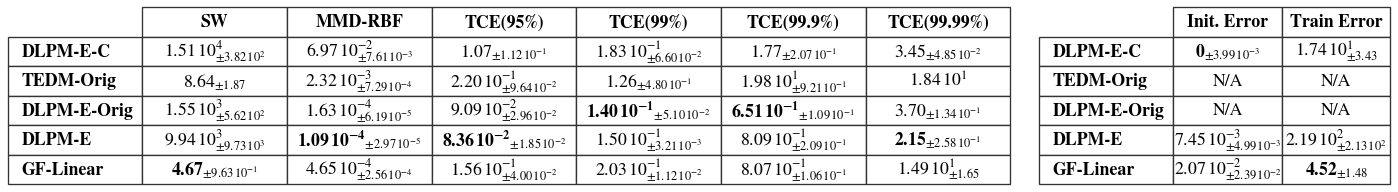

In [15]:
metrics_table = formatted.rename(columns={"SW2": "Sliced-W2", "MMD_RBF": "MMD-RBF", "TCE_95": "TCE(95)", "TCE_99": "TCE(99)", "TCE_999": "TCE(999)"})
inspect_metric_specs = {"Init. Error": "err_init", "Train Error": "err_train"}
inspect_columns = {}
for column_name, metric_name in inspect_metric_specs.items():
    valid_models = [model_name for model_name in source_order if np.isfinite(inspect_summary.loc[model_name, metric_name]["mean"])]
    best_model = None if not valid_models else min(valid_models, key=lambda model_name: max(0.0, inspect_summary.loc[model_name, metric_name]["mean"]))
    inspect_columns[column_name] = [format_mean_std_or_na(inspect_summary.loc[model_name, metric_name], bold=model_name == best_model)
                                    for model_name in source_order]

fig, axes = plt.subplots(1, 2, figsize=(9.0, 1.5), gridspec_kw={"width_ratios": [4, 1]}, squeeze=False)

render_dataframe_table(axes[0, 0], metrics_table, fontsize=8, scale=(1.0, 1.35))
render_dataframe_table(axes[0, 1], pd.DataFrame(inspect_columns, index=source_order), fontsize=8, scale=(1.0, 1.35))

fig.tight_layout()

plt.savefig(figures_dir / "tables.png", dpi=300)
plt.show()

